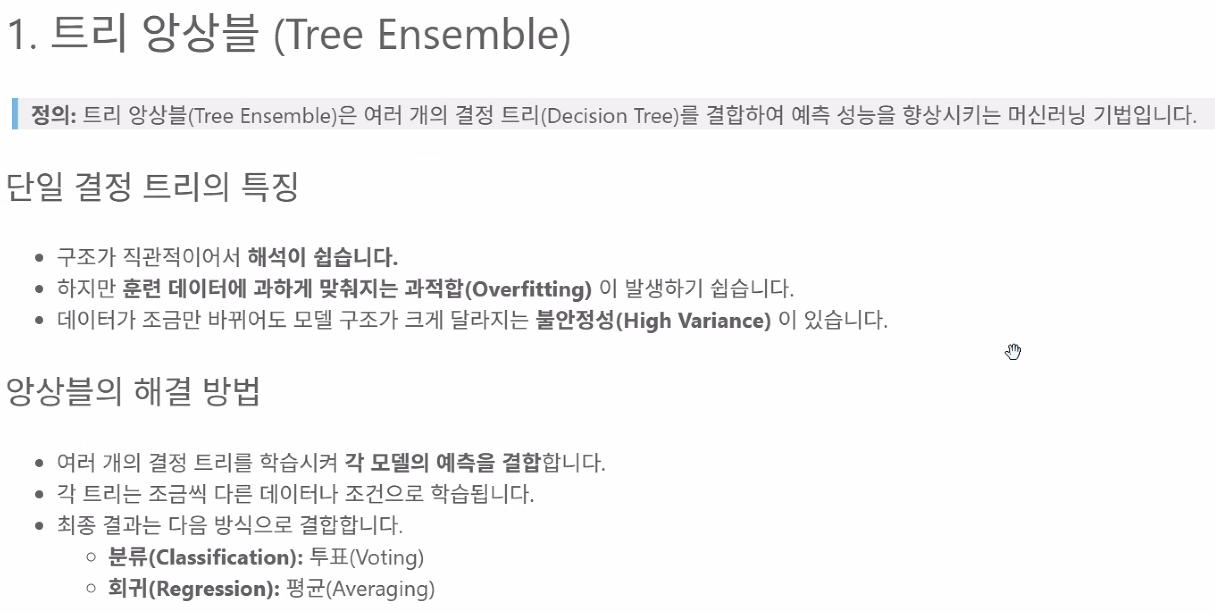

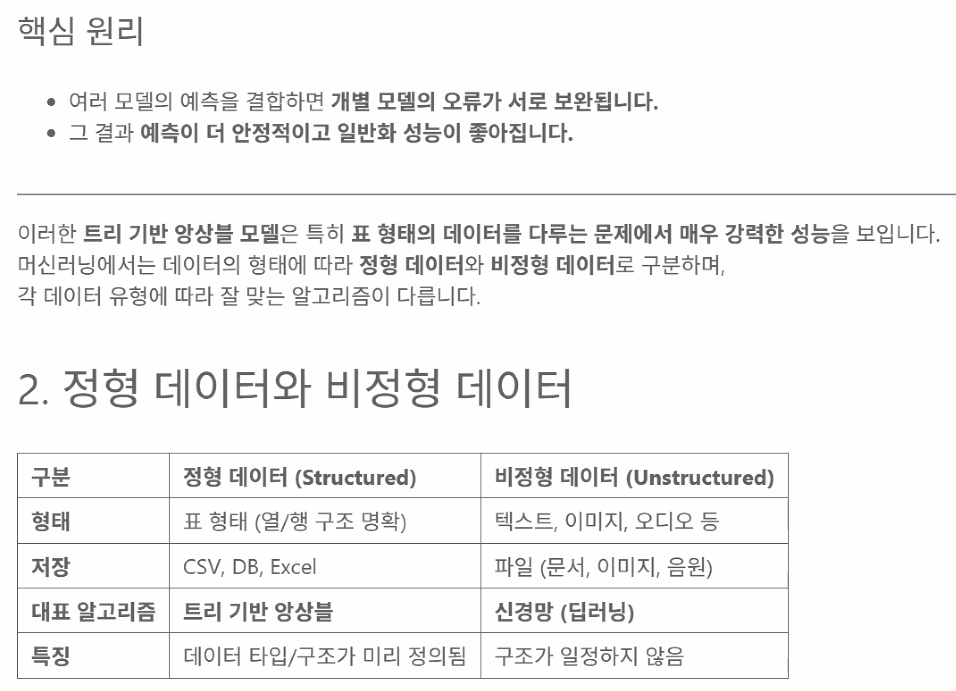

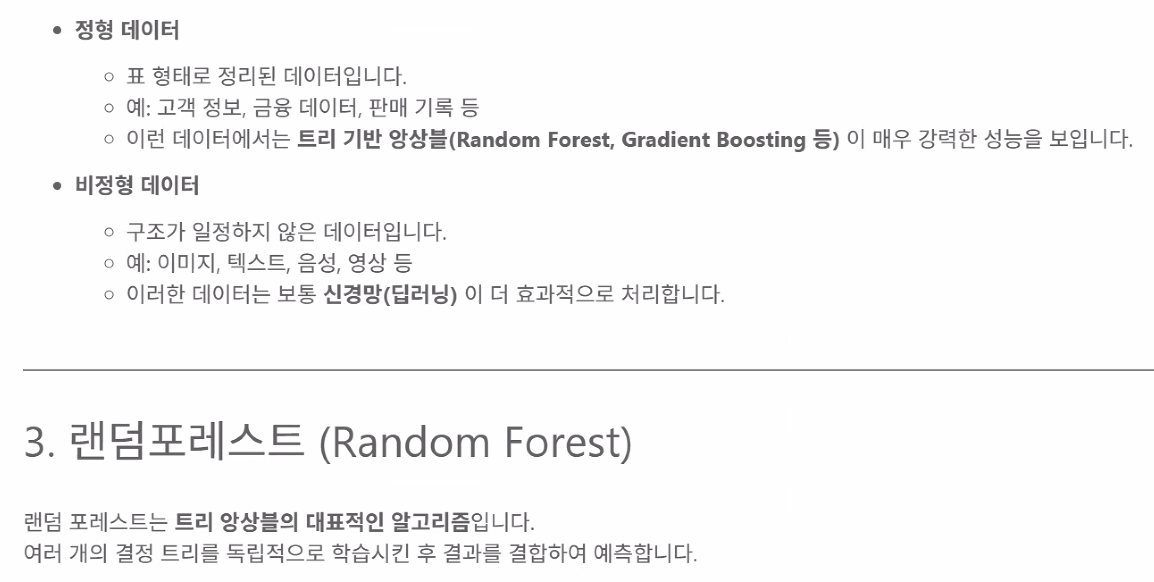

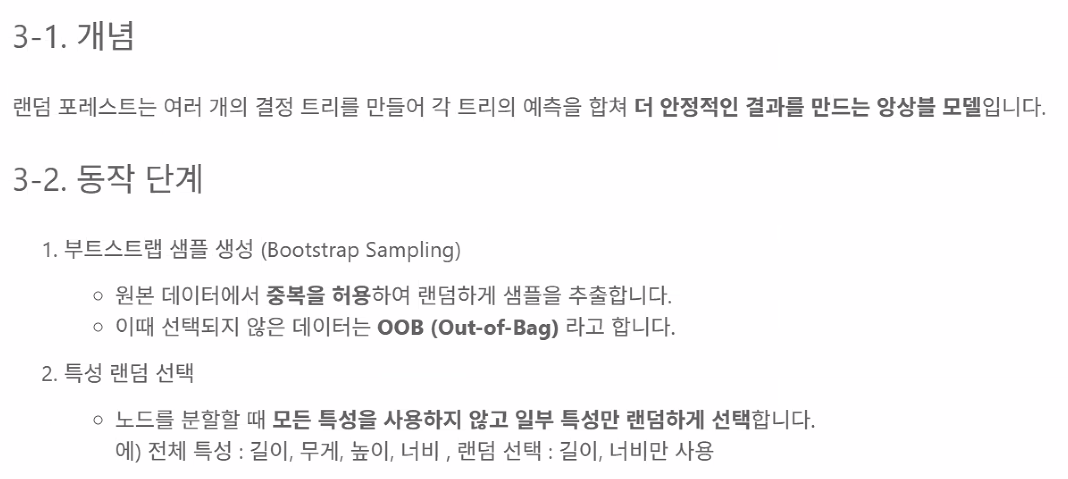

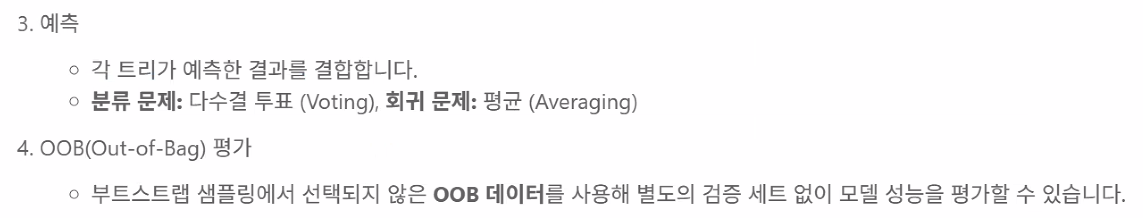

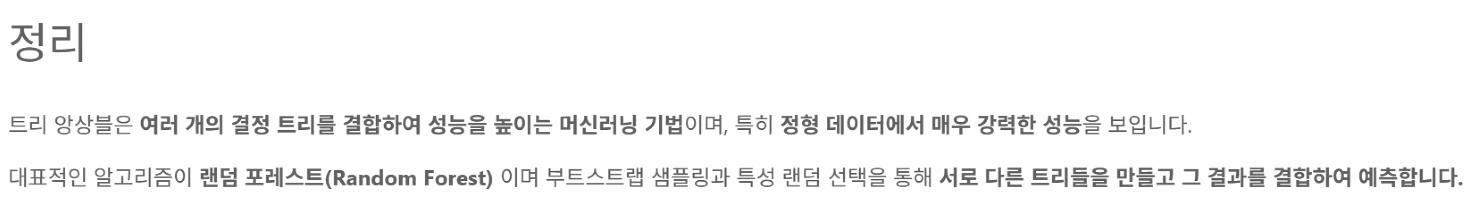

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

wine = pd.read_csv('data/wine.csv')

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

In [20]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

scores = cross_validate(rf,
                        train_input,
                        train_target,
                        return_train_score=True,
                        n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9973541965122431 0.8905151032797809


In [21]:
rf.fit(train_input, train_target)
print(rf.feature_importances_)

[0.23167441 0.50039841 0.26792718]


In [22]:
rf = RandomForestClassifier(n_jobs=-1, random_state=42, max_depth=10, min_samples_leaf=5)

scores = cross_validate(rf,
                        train_input,
                        train_target,
                        return_train_score=True,
                        n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9115357268111659 0.8783941659880062


In [23]:
rf.fit(train_input, train_target)
print(rf.feature_importances_)

[0.17494464 0.60018378 0.22487159]


In [24]:
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)

rf.fit(train_input, train_target)

print(rf.oob_score_)

0.8934000384837406


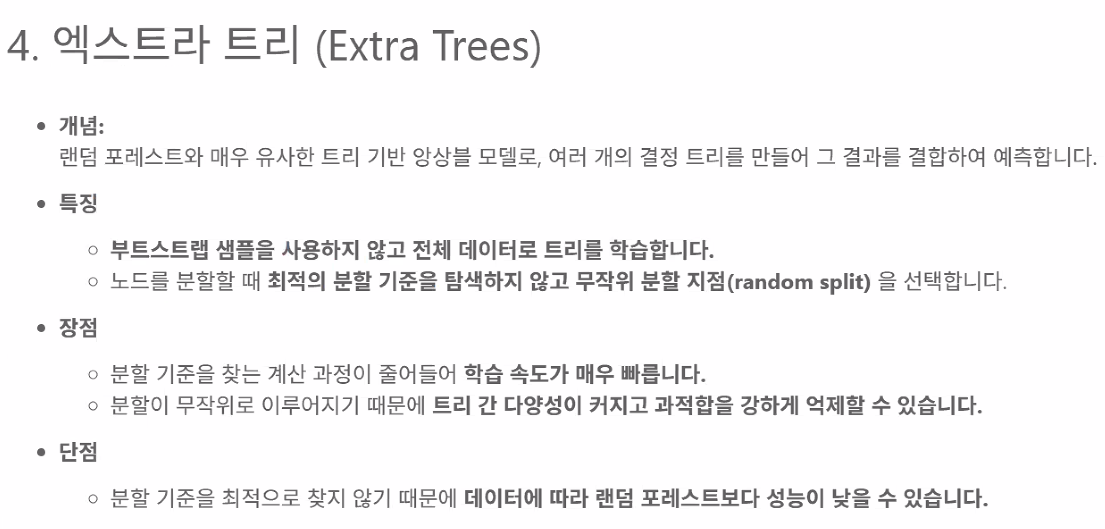

In [25]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9974503966084433 0.8887848893166506


In [26]:
et.fit(train_input, train_target)
print(et.feature_importances_)

[0.20183568 0.52242907 0.27573525]


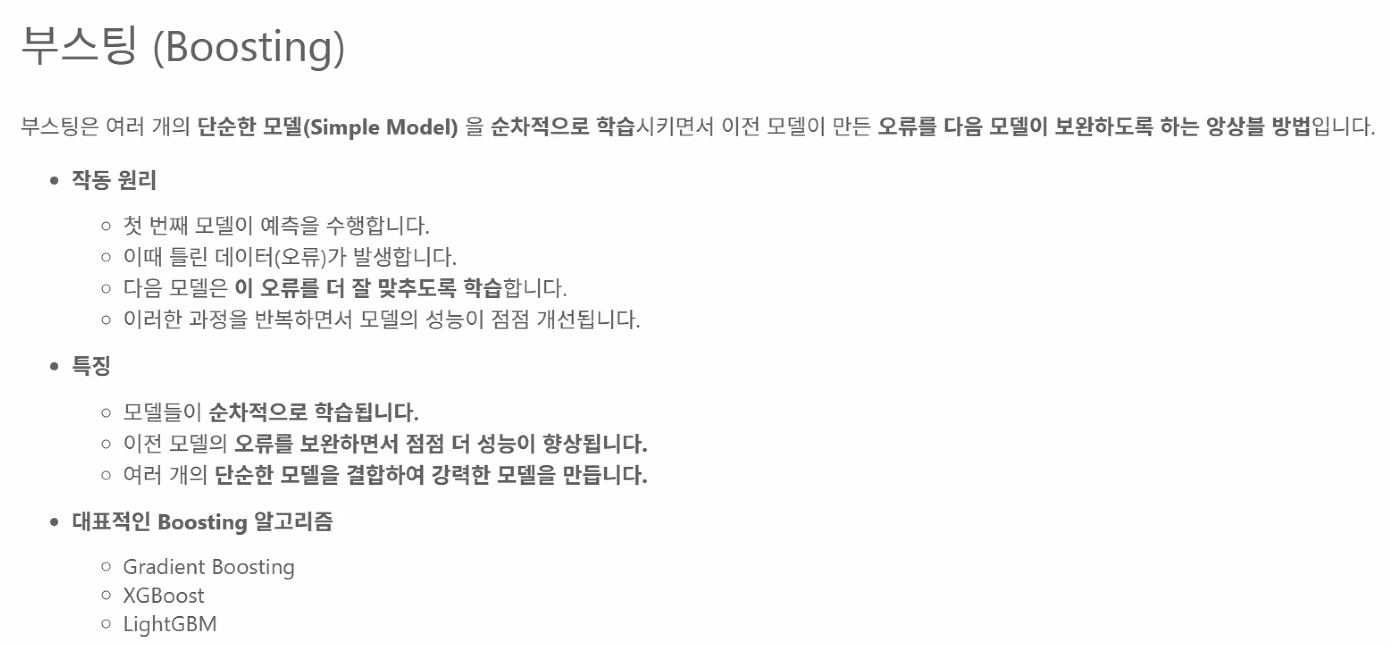

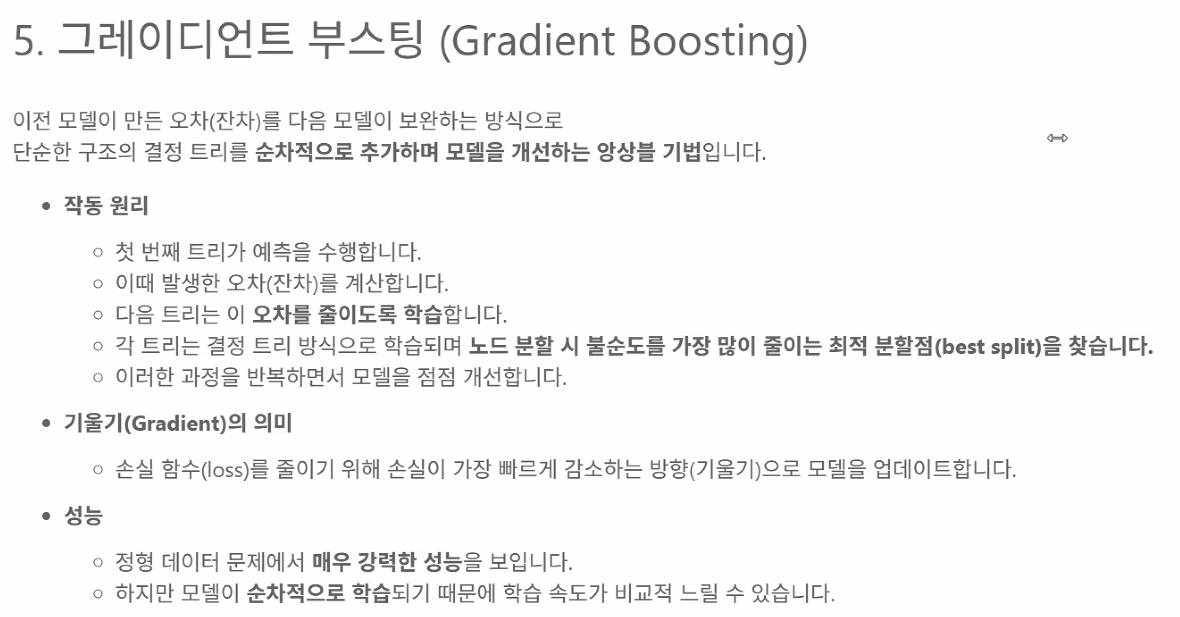

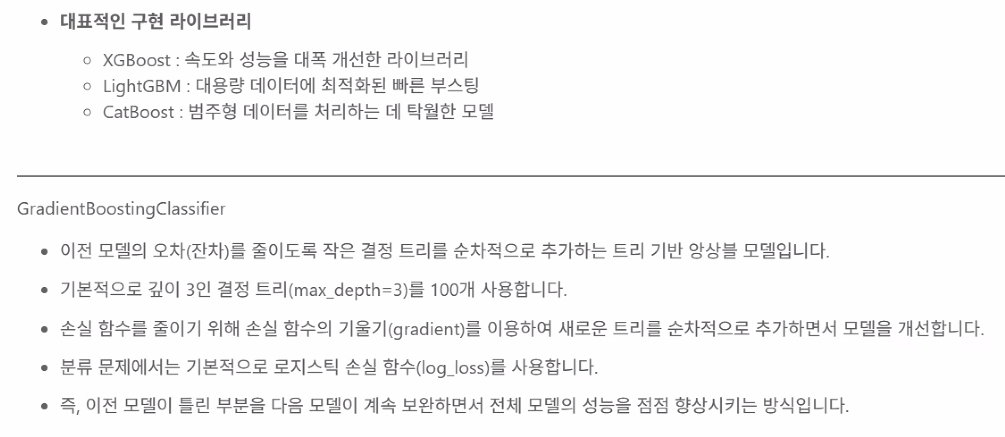

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8881086892152563 0.8720430147331015


In [28]:
gb = GradientBoostingClassifier(n_estimators=300, # 기본값 100
                                learning_rate=0.05, # 기본값 0.1
                                random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8920531592891467 0.8733902791145333


In [29]:
gb.fit(train_input, train_target)
print(gb.feature_importances_)

[0.12676547 0.73346135 0.13977318]


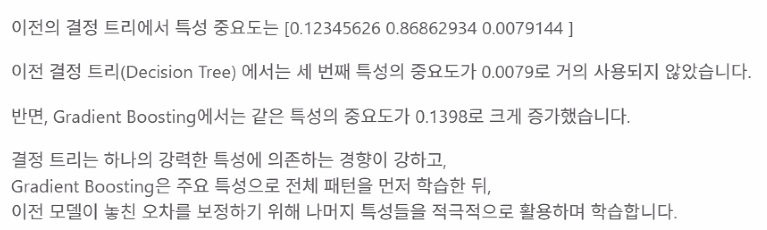

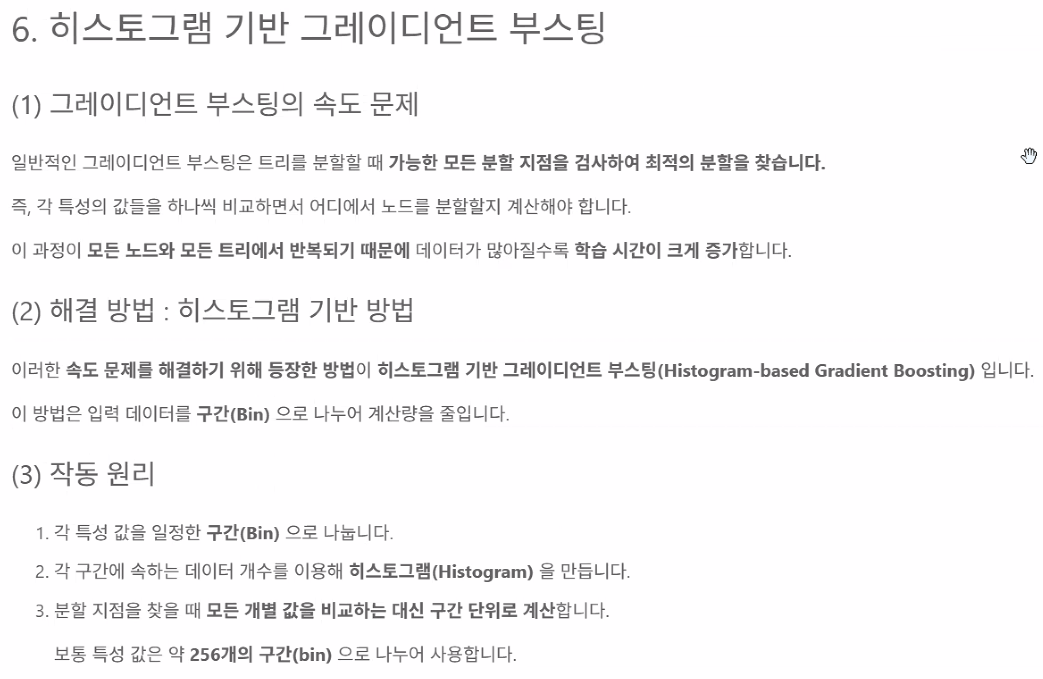

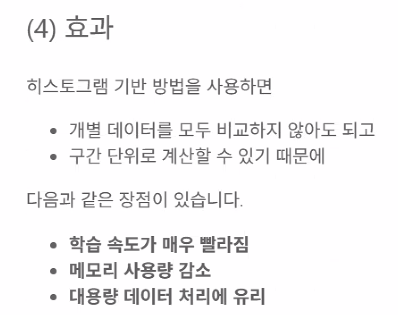

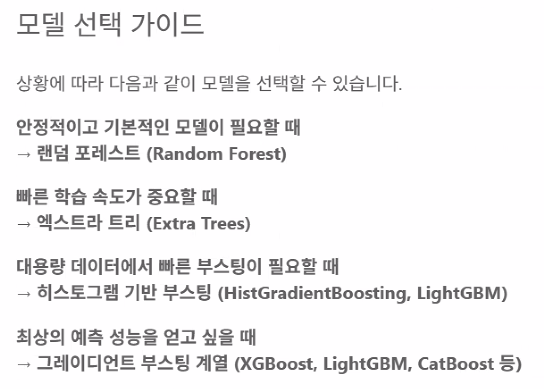

In [30]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)

scores = cross_validate(hgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9321723946453317 0.8801241948619236


In [31]:
from sklearn.inspection import permutation_importance

hgb.fit(train_input, train_target)

result = permutation_importance(hgb, train_input,
                                train_target,
                                n_repeats=10,
                                random_state=42, n_jobs=-1)

print(result.importances_mean)

[0.08876275 0.23438522 0.08027708]


In [32]:
result = permutation_importance(hgb, test_input, test_target, n_repeats=10,
                                random_state=42, n_jobs=-1)

print(result.importances_mean)

hgb.score(test_input, test_target)

[0.05969231 0.20238462 0.049     ]


0.8723076923076923

In [33]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


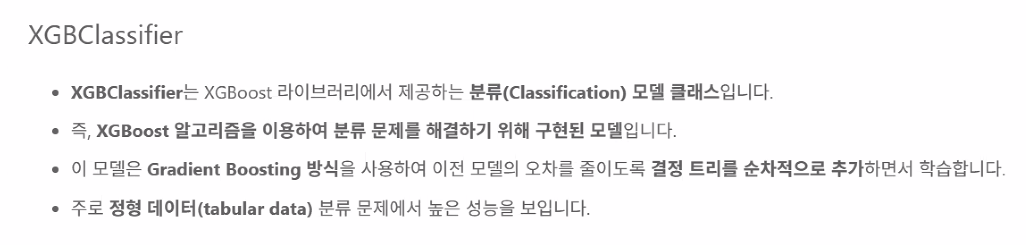

In [34]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

In [35]:
import os
os.makedirs(r"C:\temp\joblib", exist_ok=True)
os.environ["JOBLIB_TEMP_FOLDER"] = r"C:\temp\joblib"  # 영문 경로

In [36]:
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9567059184812372 0.8783915747390243


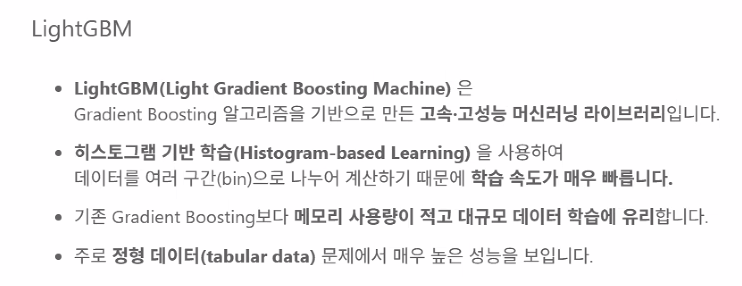

In [37]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


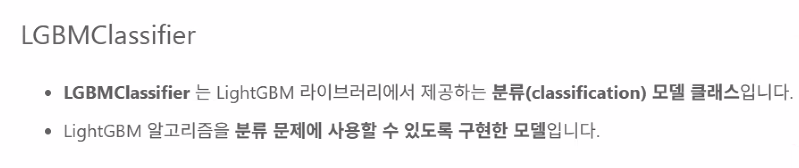

In [39]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.935828414851749 0.8801251203079884
